# imports

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import scipy.signal as signal
import numpy as np
from sklearn.cluster import KMeans
import librosa
import librosa.display
import matplotlib.pyplot as plt


# Classes 

## solver Class

In [99]:
import cvxpy as cp
import numpy as np

class Solvers:
    def __init__(self, Attentuation, delays, mixtures_stft, method_name, w_0=1, **args):
        """
        Initialize the solver with attenuation, delays, mixtures, and additional hyperparameters.
        
        Args:
        - Attentuation: Attenuation matrix (m x n).
        - delays: Delay matrix (m x n).
        - mixtures_stft: Short-time Fourier transform of mixtures.
        - method_name: Name of the method to use for optimization ('gard proximal', 'IRLS', or 'CVXPY').
        - w_0: A parameter for the frequency-related computation (default 1).
        - **args: Additional hyperparameters to be passed to the method.
        """
        self.Attentuation = Attentuation
        self.delays = delays
        self.mixtures_stft = mixtures_stft
        self.n_mix = Attentuation.shape[0]
        self.n_sources = Attentuation.shape[1]
        self.w_0 = w_0
        self.method_name = method_name
        self.args = args  # Store additional hyperparameters as a dictionary
        
    def get_method(self): 
        
        """
        Select the optimization method based on the provided method name.
        """
        if self.method_name == 'proximal': 
            return self.solve_pq_optimization_proximal
        elif self.method_name == 'IRLS': 
            return self.IRLS
        elif self.method_name == 'CVXPY':
            return self.solve_pq_optimization
        else:
            raise ValueError(f"Unknown method: {self.method_name}")
    
    def IRLS(self, A, b, **kwargs):
        """
        IRLS optimization function.
        
        Args:
        - A: Mixing matrix.
        - b: Mixture vector.
        - **kwargs: Additional hyperparameters for IRLS.
        
        Returns:
        - Estimated sources vector.
        """
        K = kwargs.get('K', 3)
        q = kwargs.get('q', 0.5)
        
        W = np.identity(A.shape[1])
        x_estim = np.ones(A.shape[1])
        
        for i in range(K):
            x_estim = W @ W @ A.T @ np.linalg.inv(A @ W @ W @ A.T) @ b
            z = np.abs(x_estim) ** (1 - q / 2)
            W = np.diag(z)
            
        return x_estim
    
    def A_l(self, l):
        """
        Compute the matrix A for a given time-frequency point [k, l].
        
        Args:
        - l: The time-frequency point index.
        
        Returns:
        - A_l: The computed mixing matrix at time-frequency point l.
        """
        A_l = np.zeros((self.n_mix, self.n_sources), dtype=complex)
        for i in range(self.n_mix):
            for j in range(self.n_sources):
                A_l[i, j] = self.Attentuation[i, j] * np.exp(-1j * 2 * np.pi * l * self.delays[i, j] * self.w_0)
        return A_l

    def __proximal_operator(self, x, **kwargs):
        """
        Proximal operator for the q-norm (non-convex for q < 1).
        
        Args:
        - x: The input vector (complex-valued).
        - **kwargs: Additional parameters like `q` and `lambda_param`.
        
        Returns:
        - The result of applying the proximal operator.
        """
        q = kwargs.get('q', 0.5)
        lambda_param = kwargs.get('lambda_param', 0.1)
        
        magnitude = np.abs(x)
        return np.sign(x) * np.maximum(magnitude - lambda_param, 0) ** q

    def __gradient_step(self, A, x, s_e, **kwargs):
        """
        Perform one step of the gradient descent.
        
        Args:
        - A: Mixing matrix.
        - x: Mixture vector.
        - s_e: Current source estimate.
        - **kwargs: Additional hyperparameters like learning_rate.
        
        Returns:
        - Updated s_e after the gradient descent step.
        """
        learning_rate = kwargs.get('learning_rate', 0.01)
        grad = A.T @ (A @ s_e - x)  # Compute the gradient of the loss
        return s_e - learning_rate * grad

    def solve_pq_optimization_proximal(self, A, x, **kwargs):
        """
        Solve the Pq optimization problem for a given time-frequency point using Proximal Gradient Descent.
        
        Args:
        - A: Mixing matrix at time-frequency point [k, l].
        - x: Mixture vector at time-frequency point [k, l].
        - **kwargs: Additional hyperparameters like `q`, `lambda_param`, `max_iter`, `learning_rate`.
        
        Returns:
        - s_e: Sparse source estimate at time-frequency point [k, l].
        """
        max_iter = kwargs.get('max_iter', 100)
        q = kwargs.get('q', 0.5)
        lambda_param = kwargs.get('lambda_param', 0.1)
        learning_rate = kwargs.get('learning_rate', 0.01)
        
        _, n = A.shape
        s_e = np.zeros(n, dtype=complex)
        
        for _ in range(max_iter):
            s_e = self.__gradient_step(A, x, s_e, learning_rate=learning_rate)
            s_e = self.__proximal_operator(s_e, q=q, lambda_param=lambda_param)
        
        return s_e

    def solve_pq_optimization(self, A, x, **kwargs):
        """
        Solve the Pq optimization problem for a given time-frequency point using CVXPY.
        
        Args:
        - A: Estimated mixing matrix at time-frequency point [k, l] (m x n).
        - x: Mixture vector at time-frequency point [k, l] (m x 1).
        - **kwargs: Hyperparameters for CVXPY optimization, like `q`, `epsilon`.
        
        Returns:
        - s_e: Sparse source estimate at time-frequency point [k, l].
        """
        q = kwargs.get('q', 0.5)
        epsilon = kwargs.get('epsilon', 1e-8)
        
        m, n = A.shape
        s_e = cp.Variable(n, complex=True)
        
        # Objective: Minimize the q-norm of s_e (sparsity measure)
        objective = cp.Minimize(cp.norm(cp.abs(s_e), q) + epsilon * cp.norm(s_e))
        
        # Constraint: A * s_e = x
        constraint = [A @ s_e == x]
        
        problem = cp.Problem(objective, constraint)
        problem.solve()
        
        return s_e.value

    def solve(self, **kwargs):
        """
        Apply the selected optimization method to all time-frequency points in the mixtures.
        
        Args:
        - **kwargs: Hyperparameters for the chosen method (q, lambda_param, max_iter, etc.)
        
        Returns:
        - estimated_sources: The estimated sources in the time-frequency domain.
        """
        estimated_sources = np.zeros((self.n_sources, self.mixtures_stft.shape[1], self.mixtures_stft.shape[2]), dtype=complex)
        
        for k in range(self.mixtures_stft.shape[2]):
            A_l = self.A_l(k)
            for l in range(self.mixtures_stft.shape[1]):
                x = np.array([self.mixtures_stft[i][l, k] for i in range(self.n_mix)])
                
                # Get the selected method and call it with the dynamic arguments
                method = self.get_method()
                s_e = method(A_l, x, **kwargs)
                
                estimated_sources[:, l, k] = s_e
        
        return estimated_sources
 

## System class 

In [100]:
class System:
    # Constructor (__init__) to initialize attributes
    def __init__(self,  mixtures, n_sources,window_size=1024,hop_length=512,sr=16000,window_type='gaussian'):
        self.n_sources=n_sources
        self.mixtures=mixtures     # Attribute for age
        self.n_mix= len(mixtures)
        self.A=np.zeros((self.n_mix,self.n_sources))
        self.hop_length=hop_length
        self.window_size=window_size
        self.sr= sr 
        self.f_0=sr / window_size
        self.window_type=window_type
        
    def compute_gabor_transform_with_f_t(self):
        gabor_transforms = []
        for signal_data in self.mixtures:
            if self.window_type == 'gaussian':
                window = signal.windows.gaussian(self.window_size, std=self.window_size / 4)
            else:
                window = signal.windows.get_window(self.window_type, self.window_size)
            self.f, self.t, Zxx = signal.stft(signal_data, nperseg=self.window_size, noverlap=self.hop_length, window=window)
            
            gabor_transforms.append(Zxx)
        self.mixtures_st_gabor=  np.array(gabor_transforms)
    def get_stfts(self):
        return  self.mixtures_st_gabor
    def plot_mixtures_stft(self,title=""):
        for i, stft in enumerate(mixtures_stft, 1):
            plt.figure(figsize=(10, 6))
            librosa.display.specshow(librosa.amplitude_to_db(np.abs(stft), ref=np.max), sr=self.sr, x_axis='time', y_axis='log')
            plt.colorbar(format='%+2.0f dB')
            plt.title(f"{title} {i} Spectrogram (Gabor Transform)" if title!="" else "Spectrogram")
            plt.show()
    def compute_feature_vectors(self):
        n_bins, n_frames = self.mixtures_st_gabor[0].shape  # Frequency bins and time frames
        # Initialize an array to hold the feature vectors
        self.feature_vectors = []
        for k in range(n_frames):
            for l in range(1,n_bins):
                # Compute the norm of the mixture coefficients at [k, l]
                norm = np.linalg.norm([self.mixtures_st_gabor[i][l, k] for i in range(self.n_mix)])
                if norm ==0 : 
                    norm=1
                # Normalize each STFT coefficient
                feature_vector = [np.abs(self.mixtures_st_gabor[i][l, k]) / norm for i in range(self.n_mix)]
            # Compute the phase difference (delays) between the mixtures
                phase_diffs = []
                for i in range(1, self.n_mix):
                    # Compute phase difference for each mixture pair
                    if  self.mixtures_st_gabor[0][l, k]==0:
                        div= 1e-7
                        phase_diffs.append(0)  
                    else : 
                        phase_diffs.append(0) 
                        
                        #div=self.mixtures_st_gabor[0][l, k] 
                        #phase_diff = -np.angle(self.mixtures_st_gabor[i][l, k] / div)/ ( l*2*np.pi*self.sr/self.window_size)
############################################################################################################################################
#the w_0= ? , comment on définie la fréquence fondamentale !! cett valeurs affecte les phase_diff donc les features vectors en clustering. Ainsi , les clusters centers vont êtres affectés
#  Ainsi la matrice de reconstruction sera déphasée 
############################################################################################################################################
                        # Append the phase difference to the list
                        #phase_diffs.append(phase_diff)  
                if  np.any(np.isnan(phase_diffs)):
                    print( 'oh no the problem is from the source',k,l)
                # Combine the normalized features and phase differences into one feature vector
                feature_vector.extend(phase_diffs)
                self.feature_vectors .append(feature_vector)
        self.feature_vectors = np.array(self.feature_vectors )
        
    def compute_k_means(self): 
        self.k_means= KMeans(n_clusters=self.n_sources)# Perform k-means clustering on the feature vectors

        self.k_means.fit(self.feature_vectors)  # 'feature_vectors' are your time-frequency features

        # Get the cluster labels for each time-frequency point
        self.labels = self.k_means.labels_
        self.cluster_centers_=self.k_means.cluster_centers_
    def get_cluster_centers_(self):
        return self.cluster_centers_
    def plot_clusters(self,indx1=0, indx2=1):
        # Visualize the clustering (optional, for 2D representation)
        plt.figure(figsize=(8, 6))
        plt.scatter(self.feature_vectors[:, indx1], self.feature_vectors[:, indx2], c=self.labels, cmap='viridis')
        plt.title("Feature Vector Clustering (k-means)")
        plt.xlabel("Feature 1 (normalized STFT coefficient)")
        plt.ylabel("Feature 2 (phase difference)")
        plt.colorbar(label='Cluster')
        plt.show()

    def estimate_aij_and_deltaij(self ):
        # Initialize arrays to store the results
        self.attenuations_est = np.zeros((self.n_mix, self.n_sources))  # Estimated attenuations (aij) for each source and mixture
        self.delays_est = np.zeros((self.n_mix, self.n_sources ))    # Estimated delays (deltaij) for each source and mixtures

        for cluster_idx in range(self.n_sources):
            # Extract the cluster center for the current cluster
            self.cluster_center_ = self.cluster_centers_[cluster_idx]            
            # The first m elements correspond to the normalized STFT coefficients (attenuations)
            self.attenuations_est[:self.n_mix,cluster_idx]= self.cluster_center_[:self.n_mix]
            # The remaining m-1 elements correspond to the phase differences (delays)
            self.delays_est[1:self.n_mix,cluster_idx]= self.cluster_center_[self.n_mix:]
    def get_attentuations_and_delats(self):
        return self.attenuations_est, self.delays_est
    def Mean_S_E_without_print(self, Matrix_atten=None, Matrix_delays=None ):
        try:
            assert self.delays_est.shape == Matrix_delays.shape,"Matrices X and Y must have the same shape"
            self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
            
        except: 
            pass
        try:
                    assert self.attenuations_est.shape == Matrix_atten.shape,"Matrices X and Y must have the same shape"
                    self.mse = np.mean((self.attenuations_est - Matrix_atten)**2) /  np.mean( Matrix_atten**2)
                    
        except:
             pass 
        

    def Mean_S_E(self, Matrix_atten=None, Matrix_delays=None ):
        try:
            assert self.delays_est.shape == Matrix_delays.shape,"Matrices X and Y must have the same shape"
            self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
            print( "The mean suqare error of delays is ", self.mse)
            print("The True matrix is \n", Matrix_delays.T)
            print("The estiamted matrix is \n", self.delays_est.T)
        except: 
            pass
        try:
                    assert self.attenuations_est.shape == Matrix_atten.shape,"Matrices X and Y must have the same shape"
                    self.mse = np.mean((self.attenuations_est - Matrix_atten)**2) /  np.mean( Matrix_atten**2)
                    print( "The mean suqare error of attenutaion is ", self.mse)
                    print("The True matrix is \n", Matrix_atten.T)
                    print("The estiamted matrix is \n", self.attenuations_est.T)
        except:
             pass

    
    def ecarser_attentuation_delays( self, A=None,D=None): 
        if A != None: 
            self.attenuations_est= A 
        if D != None:
            self.delays_est= D
    
    def simulate_sources_stft(self,method_name='IRLS',method_params={}):
        if method_name == 'IRLS':
            solver_irls = Solvers(self.attenuations_est,self.delays_est, self.mixtures_st_gabor, method_name, w_0=2 * np.pi * self.f_0, **method_params)
            self.stft_sources = solver_irls.solve(**method_params)
        elif method_name == 'proximal':
            solver_proximal = Solvers(self.attenuations_est,self.delays_est,self.mixtures_st_gabor, method_name, w_0=2 * np.pi * self.f_0, **method_params)
            self.stft_sources = solver_proximal.solve(**method_params)
        elif method_name == 'CVXPY':
            solver_cvxpy = Solvers(self.attenuations_est,self.delays_est, self.mixtures_st_gabor, method_name='CVXPY', w_0=1, **method_params)
            self.stft_sources = solver_cvxpy.solve(**method_params)
        return self.stft_sources
    def get_sources_stft(self):
        return self.stft_sources

## Tools for gini index 

In [101]:
def Aire(lorenz):
    """Computes the area A(x) under the Lorenz curve using the formula:
        A(x) = 1 / (2N) * sum(L(n-1/N) + L(n/N)) for all n
    """
    N = len(lorenz) 
    area = 0
    for n in range(1, N+1):
        area += (lorenz[n-1] + lorenz[n-1 if n == N else n]) / N
    return 0.5 * area
def gini_index(A, matrix = True  ): 
    if  matrix : 
        A= A.reshape(-1)
    sorted_signal = np.sort(np.abs(A))
    cumulative_sum = np.cumsum(sorted_signal) 
    lorenz = cumulative_sum / cumulative_sum[-1]
    area = Aire(lorenz)
    gini = 1 - 2 * area
    return gini

# experiment

## generer des sources 


The 0-th frequency is 322 Hz
The 1-th frequency is 884 Hz
The 2-th frequency is 6014 Hz


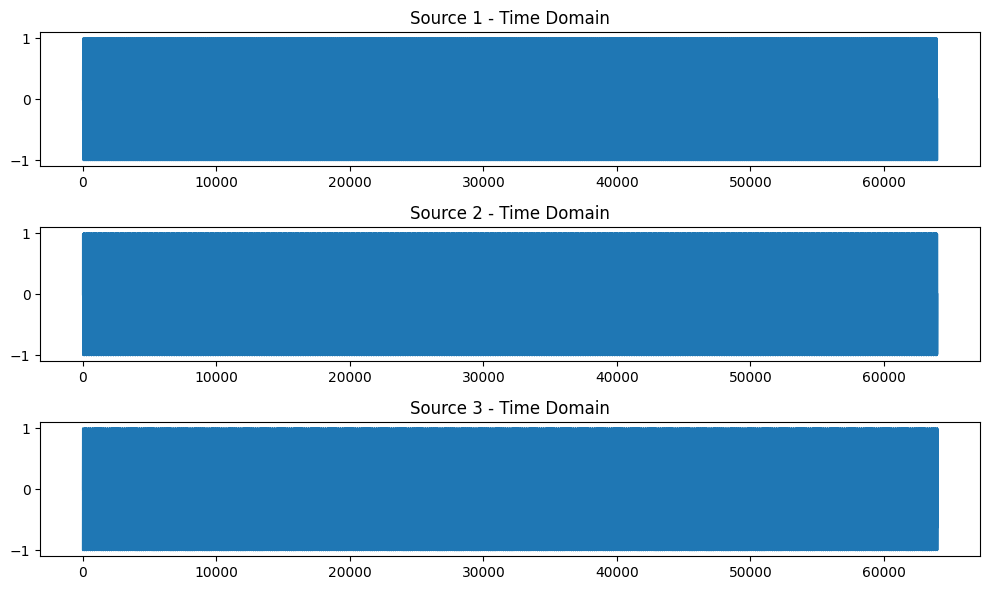

In [102]:


# Parameters
n_sources = 3 # Number of sources (speech signals)
n_mixtures = 2  # Number of mixtures
duration = 4  # Duration of the signals in seconds
sr = 16000 #16000  # Sample rate

# Function to generate synthetic sources with sufficiently spaced frequencies
def generate_sources(n, duration, sr=16000, f_min=10, f_max=500, min_spacing=50, print_f= True ):
    t = np.linspace(0, duration, int(duration * sr))
    sources = []
    frequencies = []  # To store the generated frequencies
    
    for i in range(n):
        while True:
            # Generate a random frequency for each source
            frequency = np.random.randint(f_min, f_max)
            
            # Check if the frequency is sufficiently spaced from the existing ones
            if all(abs(frequency - f) >= min_spacing for f in frequencies):
                frequencies.append(frequency)
                break  # If valid, add it and break out of the loop
        
        # Generate the sine wave for the source
        source = np.sin(2 * np.pi * frequency * t)  # Sine wave with the generated frequency
        if print_f: 
            print(f'The {i}-th frequency is {frequency} Hz')  # Print the frequency for each source
        sources.append(source)
    
    return np.array(sources)

# Function to plot the time-domain signals
def plot_time_domain_signals(sources, sr=sr, sr_or_mix= 'Source'):
    plt.figure(figsize=(10, 6))
    for i, source in enumerate(sources):
        plt.subplot(len(sources), 1, i + 1)
        plt.plot(source)
        plt.title(f"{sr_or_mix} {i + 1} - Time Domain")
    plt.tight_layout()
    plt.show()




f_min = 10
f_max = 8000
min_spacing = (f_max-f_min)// 20# Minimum spacing between frequencies


# Generate synthetic sources with sufficient frequency spacing
sources = generate_sources(n_sources, duration, sr, f_min=f_min, f_max=f_max, min_spacing=min_spacing)

# Plot the time-domain signals
plot_time_domain_signals(sources, sr, 'Source')


## deduct mixtures

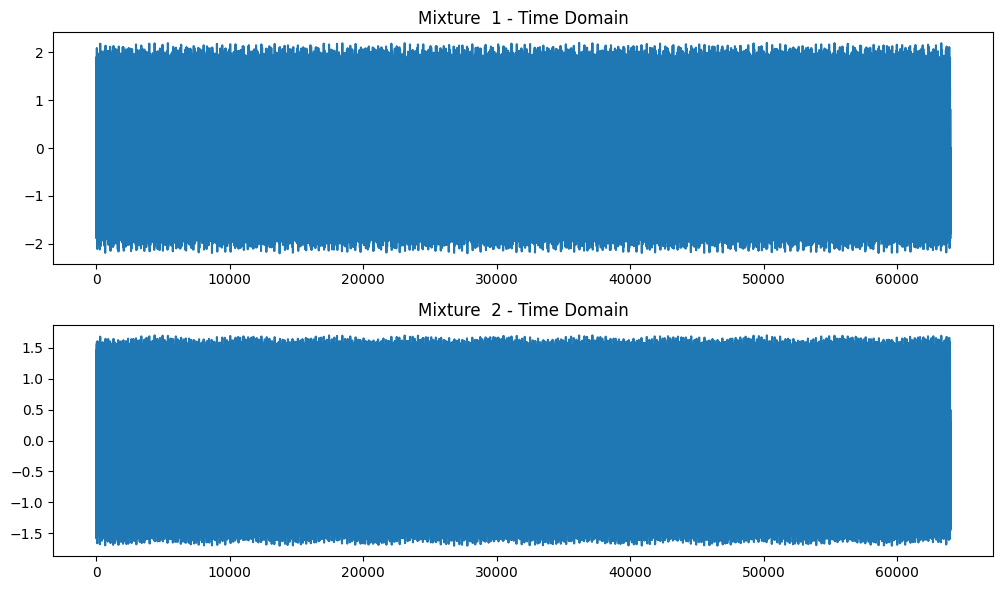

In [103]:
def delay_source(source, rank ):
    delayed= np.roll(source, rank)
    delayed[0:rank]=np.zeros(rank)
    return delayed
# Function to simulate the mixing model

# Function to simulate the mixing model
def simulate_mixing(sources, mixing_matrix, delays, sr=16000):
    m, n = mixing_matrix.shape
    mixtures = np.zeros((m, len(sources[0])))  # Initialize mixtures matrix
    
    for i in range(m):
        for j in range(n):
            # Apply delays and attenuations
            delayed_source =  delay_source(sources[j],  int(delays[i, j] * sr)) 
            mixtures[i] += mixing_matrix[i, j] * delayed_source
    
    return mixtures


# Define a mixing matrix A (n_mixtures x n_sources)
mixing_matrix = np.random.rand(n_mixtures, n_sources)  # Random mixing matrix
mixing_matrix = mixing_matrix / np.linalg.norm(mixing_matrix, axis=0)  # Normalize columns


# Define delays between sources (in seconds)
delays = np.random.rand(n_mixtures, n_sources) *0 # Random delays between sources
delays[0,:]= np.zeros(n_sources)

# Simulate the mixing process
mixtures = simulate_mixing(sources, mixing_matrix, delays, sr)

plot_time_domain_signals(mixtures, sr_or_mix="Mixture ")

## genrer les STFT 

In [104]:
n_fft_0= 1024 
hop_length_0=512
# Function to compute the Gabor transform of signals
def compute_gabor_transform_with_f_t(signals, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian'):
    gabor_transforms = []
    for signal_data in signals:
        if window_type == 'gaussian':
            window = signal.windows.gaussian(window_size, std=window_size / 4)
        else:
            window = signal.windows.get_window(window_type, window_size)
        f, t, Zxx = signal.stft(signal_data, nperseg=window_size, noverlap=hop_length, window=window)
        
        gabor_transforms.append(Zxx)
    return np.array(gabor_transforms),f,t
mixtures_stft,f,t = compute_gabor_transform_with_f_t(mixtures, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian')
sources_stft,f,t = compute_gabor_transform_with_f_t(sources, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian')
# Function to plot the spectrogram of a signal
def plot_spectrogram(stft_matrix, sr=sr, title="Spectrogram"):
    plt.figure(figsize=(10, 6))
    print( np.max(np.abs(stft_matrix)))
    librosa.display.specshow(librosa.amplitude_to_db(np.abs(stft_matrix), ref=np.max), sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.show()



In [105]:

window_size= 1024
hop_length=512
n_fft_0= 1024 
hop_length_0=512
# Function to compute the Gabor transform of signals
def compute_gabor_transform_with_f_t(signals, window_size=window_size, hop_length=hop_length, window_type='gaussian'):
    gabor_transforms = []
    for signal_data in signals:
        if window_type == 'gaussian':
            window = signal.windows.gaussian(window_size, std=window_size / 4)
        else:
            window = signal.windows.get_window(window_type, window_size)
        f, t, Zxx = signal.stft(signal_data, nperseg=window_size, noverlap=hop_length, window=window)
        
        gabor_transforms.append(Zxx)
    return np.array(gabor_transforms),f,t
mixtures_stft,f,t = compute_gabor_transform_with_f_t(mixtures, window_size=window_size, hop_length=hop_length, window_type='gaussian')
sources_stft,f,t = compute_gabor_transform_with_f_t(sources, window_size=window_size, hop_length=hop_length, window_type='gaussian')
# Function to plot the spectrogram of a signal
def plot_spectrogram(stft_matrix, sr=sr, title="Spectrogram"):
    plt.figure(figsize=(10, 6))
    
    librosa.display.specshow(librosa.amplitude_to_db(np.abs(stft_matrix), ref=np.max), sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.show()



the gini index of this stft =  0.909867290660733


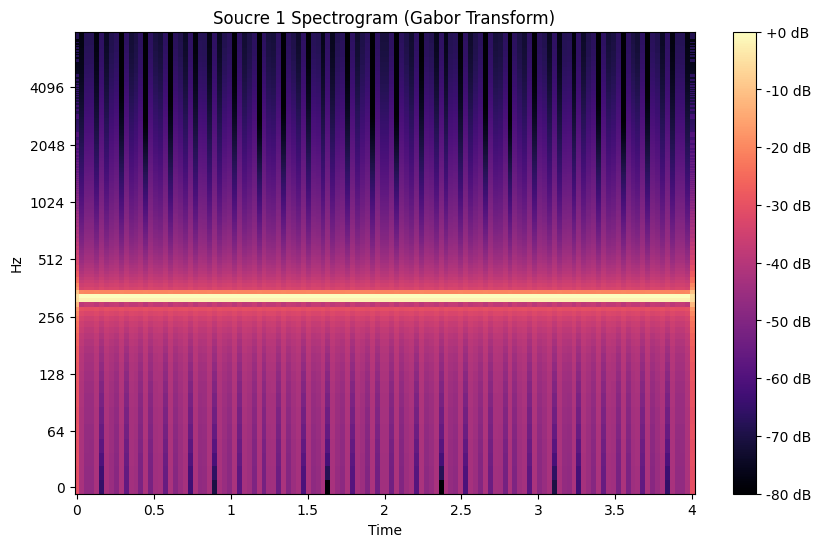

the gini index of this stft =  0.8963822281806327


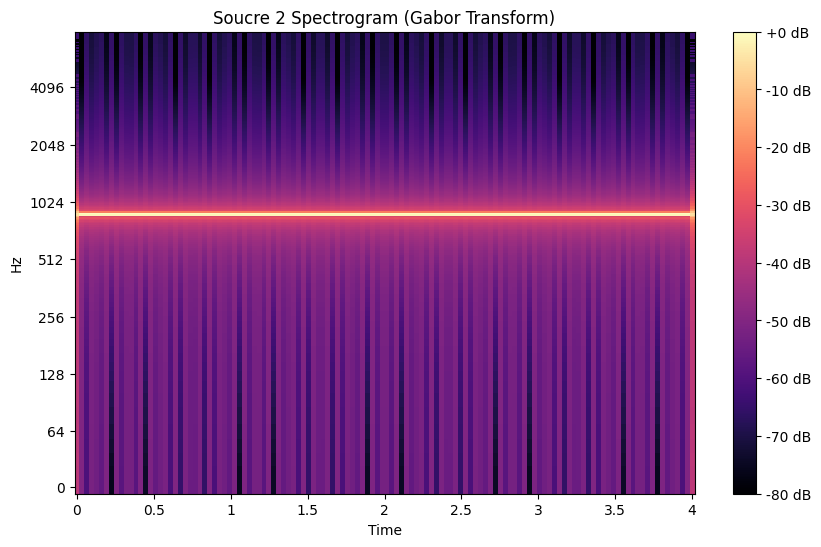

the gini index of this stft =  0.951476226000381


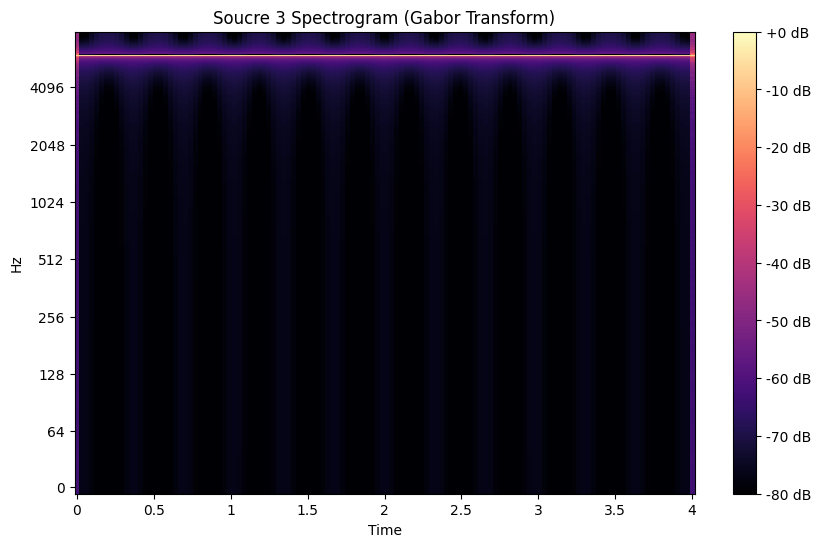

the gini index of this stft =  0.9187137066766295


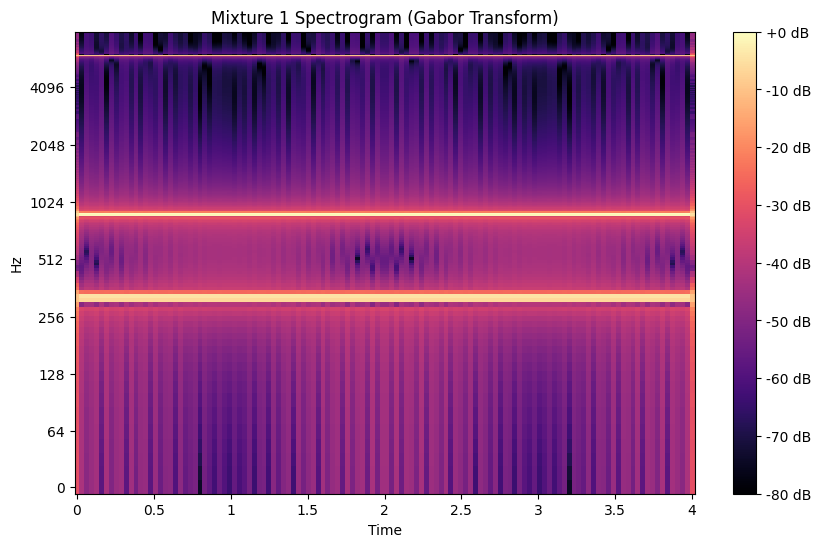

the gini index of this stft =  0.9229732452115438


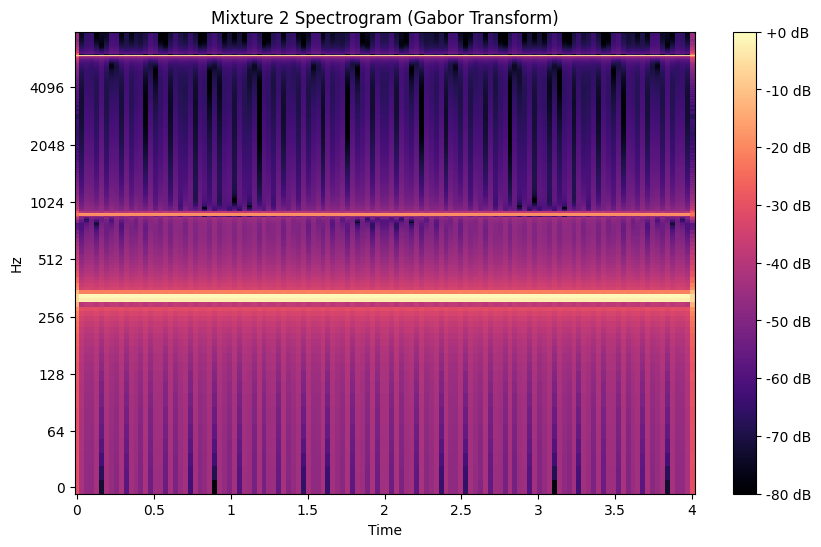

In [106]:
for i, stft in enumerate(sources_stft, 1):
    print( "the gini index of this stft = ", gini_index(stft,matrix=True))
    plot_spectrogram(stft, sr=sr, title=f"Soucre {i} Spectrogram (Gabor Transform)")
for i, stft in enumerate(mixtures_stft, 1):
    print( "the gini index of this stft = ", gini_index(stft,matrix=True))
    plot_spectrogram(stft, sr=sr, title=f"Mixture {i} Spectrogram (Gabor Transform)")


# Test the performance of the system  for n sources and m mixtures  n>m 

In [107]:
results={}
maxi_sources= 10
maxi_capteurs= 10
window_size= 1024
hop_length= 512
N_essays= 10
eps=0.05
n_sources= 4
duration= 4
sr= 16000
f_max= 8000
f_min= 10
min_spacing= ( f_max-f_min)//20
for n_mixtures in range(2,maxi_capteurs): 
    for n_sources in range(n_mixtures,maxi_sources ):
        print("Test: n_mixtures =", n_mixtures, "     n_sources = " , n_sources)
        sources = generate_sources(n_sources, duration, sr, f_min=f_min, f_max=f_max, min_spacing=min_spacing, print_f= False)
        mixing_matrix = np.random.rand(n_mixtures, n_sources)  # Random mixing matrix
        mixing_matrix = mixing_matrix / np.linalg.norm(mixing_matrix, axis=0)  # Normalize columns
        delays = np.random.rand(n_mixtures, n_sources) *0 
        mixtures = simulate_mixing(sources, mixing_matrix, delays, sr)
        system1= System(mixtures, n_sources, window_size= window_size,hop_length=hop_length,sr= sr)
        system1.compute_gabor_transform_with_f_t()
        system1.compute_feature_vectors()
        best_mse=np.inf
        best_attentuation= None
        for _ in range(N_essays): 
            system1.compute_k_means()
            system1.estimate_aij_and_deltaij()
            system1.delays_est=system1.delays_est 
            system1.Mean_S_E_without_print(mixing_matrix,delays)
            if system1.mse < best_mse : 
                best_attentuation = system1.attenuations_est
            if system1.mse < eps : 
                break
        system1.attenuations_est= best_attentuation
        system1.Mean_S_E_without_print(mixing_matrix,delays)
        results[n_mixtures,n_sources ]= system1.mse
        print( "The mean suqare error of attenutaion is ", system1.mse)
        
        
                


Test: n_mixtures = 2      n_sources =  2


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)


The mean suqare error of attenutaion is  0.00863891276599793
Test: n_mixtures = 2      n_sources =  3


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide

The mean suqare error of attenutaion is  0.015986126105136163
Test: n_mixtures = 2      n_sources =  4


...

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide

The mean suqare error of attenutaion is  0.2131246052034781
Test: n_mixtures = 9      n_sources =  9


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide

The mean suqare error of attenutaion is  0.3425840047936052


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)


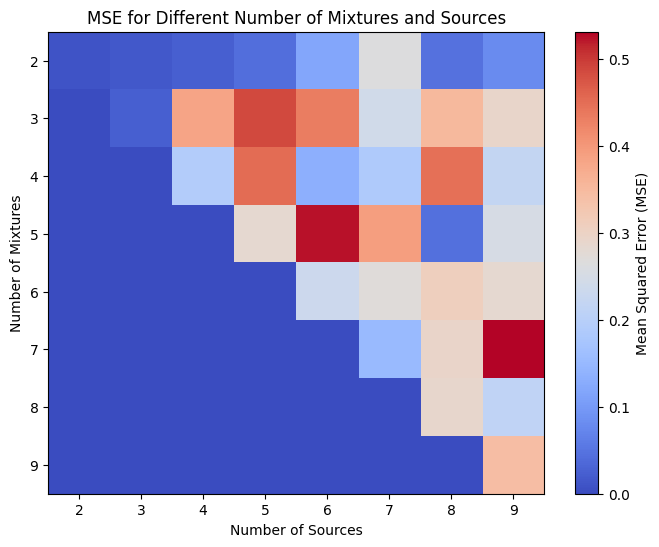

In [108]:
mse_matrix = np.zeros((maxi_capteurs-2, maxi_sources-2))

for n_mixtures in range(2, maxi_capteurs):
    for n_sources in range(n_mixtures, maxi_sources):
        mse_matrix[n_mixtures-2, n_sources-2] = results.get((n_mixtures, n_sources), np.nan)

# Plotting the results as a heatmap
plt.figure(figsize=(8, 6))
plt.imshow(mse_matrix, aspect='auto', cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Mean Squared Error (MSE)')
plt.title('MSE for Different Number of Mixtures and Sources')
plt.xlabel('Number of Sources')
plt.ylabel('Number of Mixtures')
plt.xticks(ticks=np.arange(maxi_sources-2), labels=np.arange(2, maxi_sources))
plt.yticks(ticks=np.arange(maxi_capteurs-2), labels=np.arange(2, maxi_capteurs))
plt.show()

In [109]:
results

{(2, 2): 0.00863891276599793,
 (2, 3): 0.015986126105136163,
 (2, 4): 0.024781524470902993,
 (2, 5): 0.043012947018733504,
 (2, 6): 0.12028476832748501,
 (2, 7): 0.2635999199909263,
 (2, 8): 0.047662289645228464,
 (2, 9): 0.0804940133933693,
 (3, 3): 0.02341718748295395,
 (3, 4): 0.3827070867388713,
 (3, 5): 0.48651013877350857,
 (3, 6): 0.4334780243526445,
 (3, 7): 0.24108361627395966,
 (3, 8): 0.3519618518922804,
 (3, 9): 0.2908791038246995,
 (4, 4): 0.1912949722999164,
 (4, 5): 0.45153710610330666,
 (4, 6): 0.1342382632505954,
 (4, 7): 0.18590466837555525,
 (4, 8): 0.44700525343182707,
 (4, 9): 0.2197065346374357,
 (5, 5): 0.28396529956846733,
 (5, 6): 0.5244411122106353,
 (5, 7): 0.39007523739126554,
 (5, 8): 0.04433056257313049,
 (5, 9): 0.2525208369818839,
 (6, 6): 0.2342384056139754,
 (6, 7): 0.27020508657600384,
 (6, 8): 0.30879838641822327,
 (6, 9): 0.2832320696049821,
 (7, 7): 0.15348269142013526,
 (7, 8): 0.2942772684150114,
 (7, 9): 0.5310790525336522,
 (8, 8): 0.2889455112

# experiement for diffferent solvers 

la meilleur cas est de 2 capteurs avec 3 signaux 
le cas standard est  de 3 capteurs avec 5 signaux 
le cpire des cas  est  de 2 capteurs avec 8 signaux 

In [110]:
method_names=['IRLS','proximal','CVXPY']
method_parameters={}
method_parameters['proximal']= {'q': 0.001, 'lambda_param': 0.001, 'max_iter': 2*150}

method_parameters['IRLS']= {'K': 50 , 'q': 0.001}
method_parameters['CVXPY']={'q': 1, 'epsilon': 1e-8}

The 0-th frequency is 987 Hz
The 1-th frequency is 1630 Hz
The 2-th frequency is 2639 Hz
###################################################The method is  IRLS #########################################################################


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)


The mean suqare error of attenutaion is  0.026601643012920024
the gini index of this stft =  0.9626670653609519


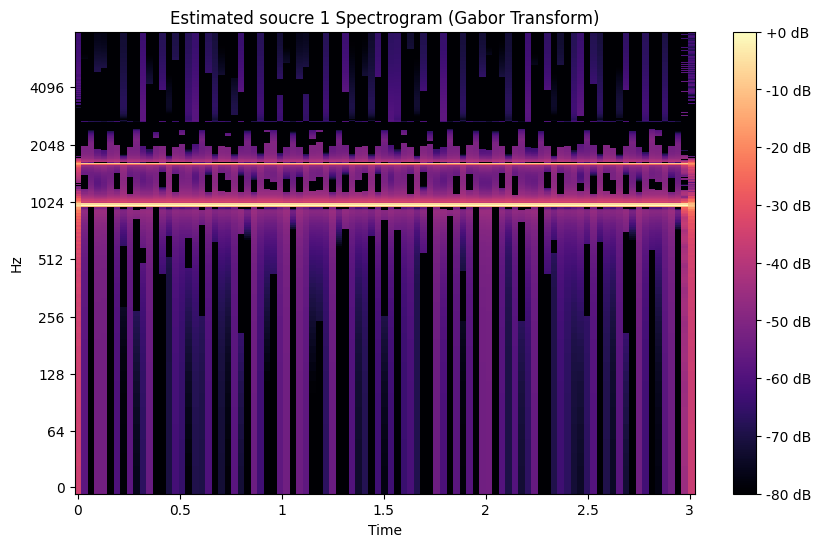

the gini index of this stft =  0.933982408801697


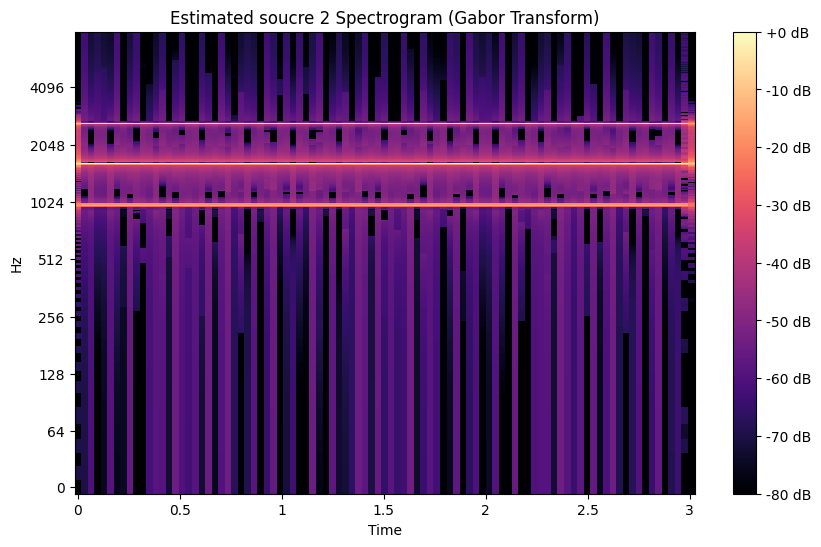

the gini index of this stft =  0.9723770850307134


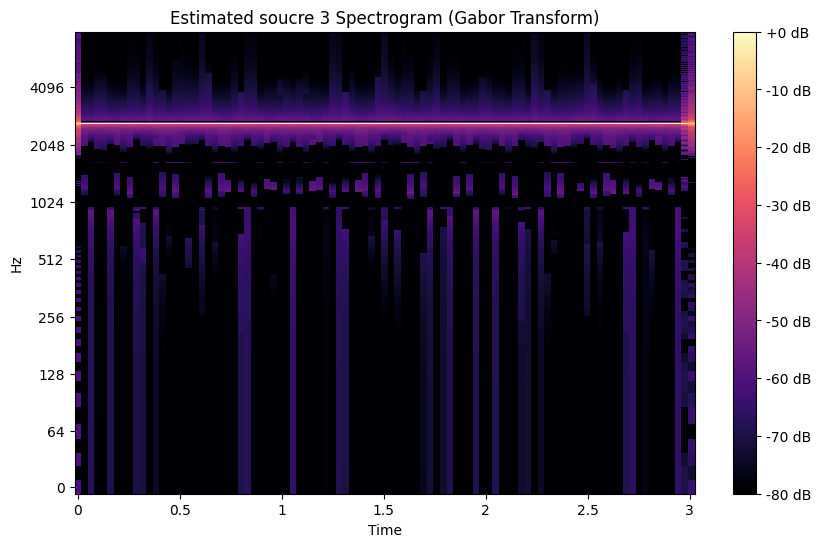

###################################################The method is  proximal #########################################################################


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide

The mean suqare error of attenutaion is  0.02651623177066165
the gini index of this stft =  0.9843234623195403


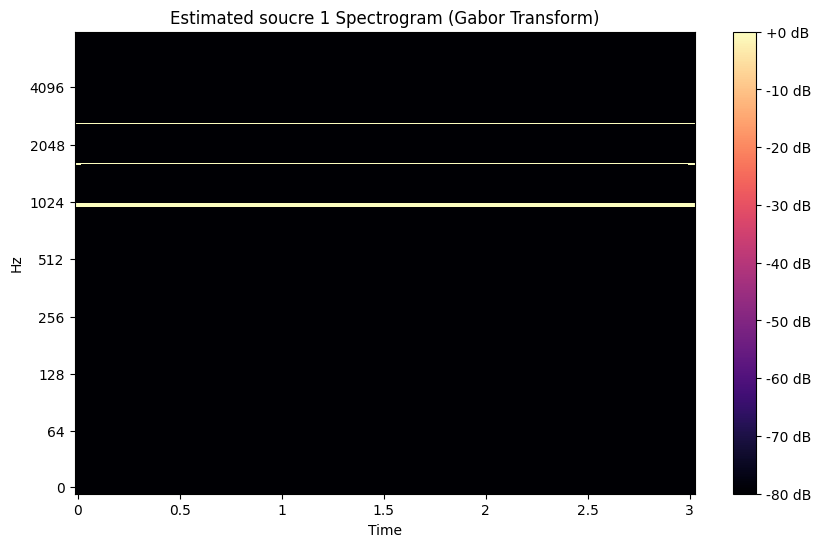

the gini index of this stft =  0.9843234602401771


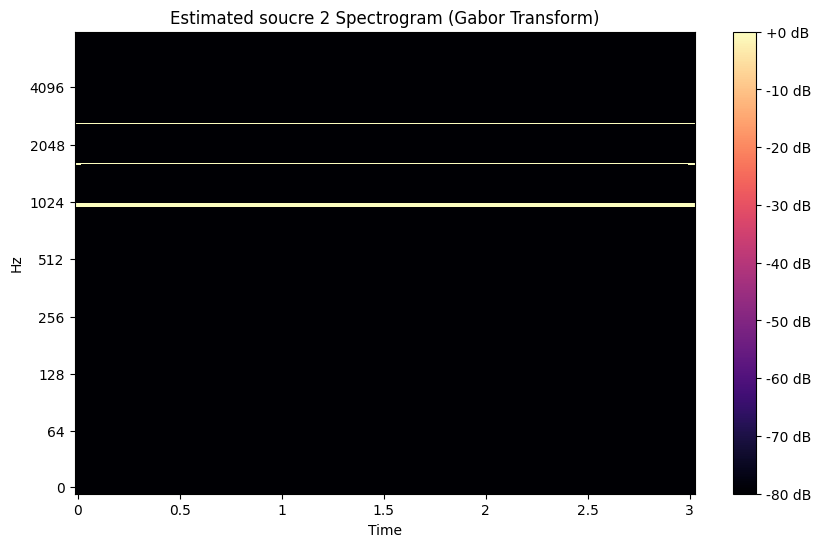

the gini index of this stft =  0.9843234386865815


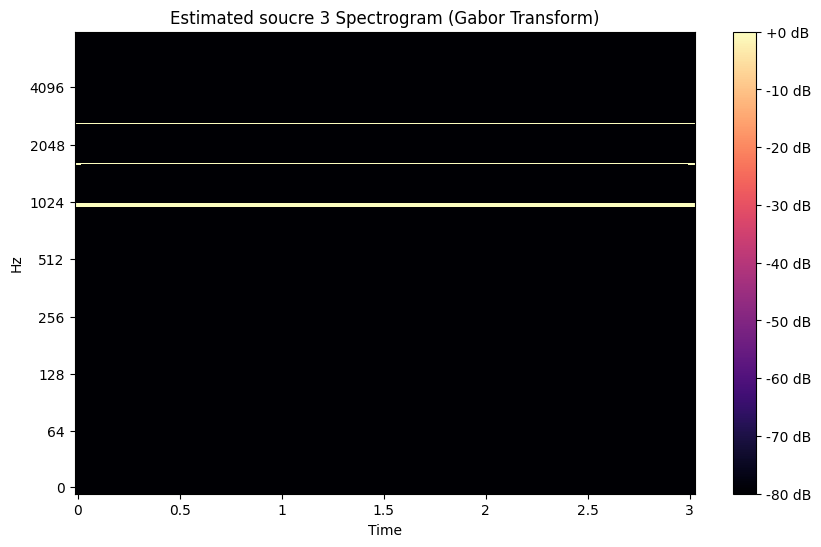

###################################################The method is  CVXPY #########################################################################


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)


The mean suqare error of attenutaion is  0.02658215050948241
the gini index of this stft =  0.971014970088076


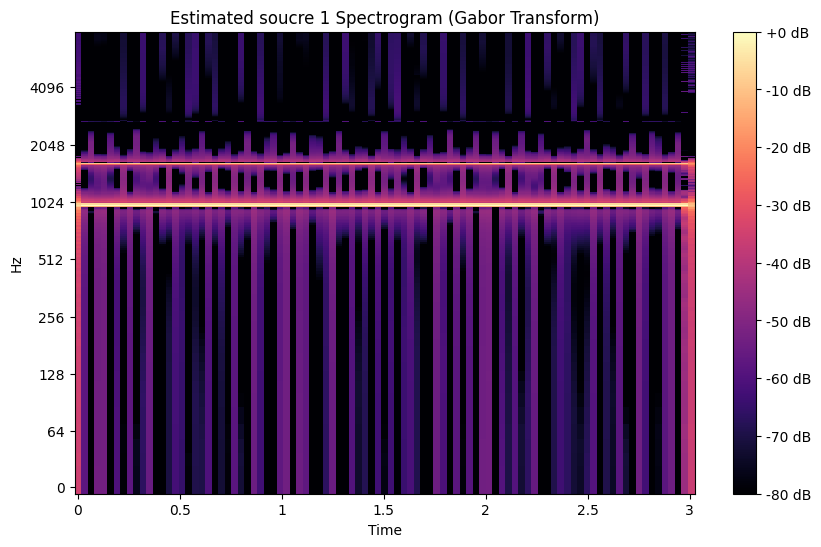

the gini index of this stft =  0.9278774831029684


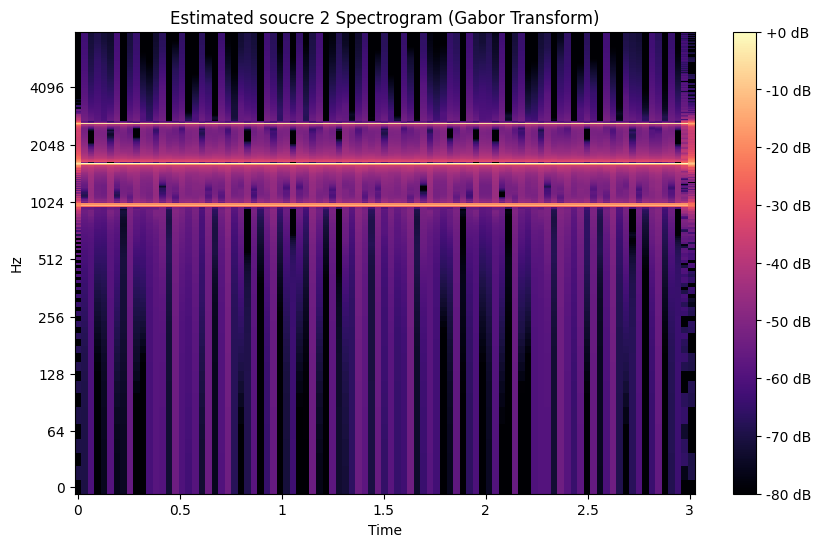

the gini index of this stft =  0.9633823205127104


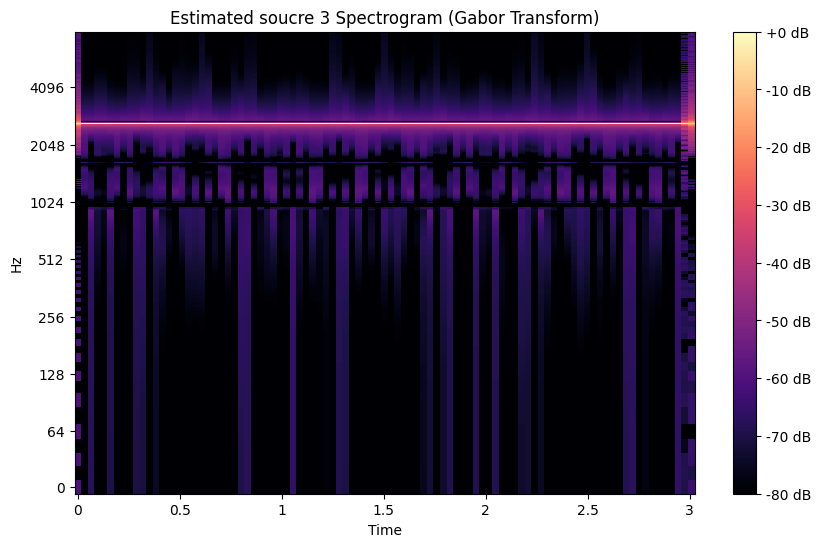

In [111]:
n_sources = 3
n_mixtures = 2 
duration = 3
sr=16000
f_max= 8000
f_min = 10 
min_spacing= (f_max- f_min)//20
results_method={}
sources = generate_sources(n_sources, duration, sr, f_min=f_min, f_max=f_max, min_spacing=min_spacing)
mixing_matrix = np.random.rand(n_mixtures, n_sources)  # Random mixing matrix
mixing_matrix = mixing_matrix / np.linalg.norm(mixing_matrix, axis=0)  # Normalize columns
delays = np.random.rand(n_mixtures, n_sources) *0 
mixtures = simulate_mixing(sources, mixing_matrix, delays, sr)
for mn in method_names: 
    print("###################################################The method is ",mn , "#########################################################################")
    system1= System(mixtures, n_sources, window_size= window_size,hop_length=hop_length,sr= sr)
    system1.compute_gabor_transform_with_f_t()
    system1.compute_feature_vectors()
    best_mse=np.inf
    best_attentuation= None
    for _ in range(N_essays): 
          system1.compute_k_means()
          system1.estimate_aij_and_deltaij()
          system1.delays_est=system1.delays_est 
          system1.Mean_S_E_without_print(mixing_matrix,delays)
          if system1.mse < best_mse : 
               best_attentuation = system1.attenuations_est
          if system1.mse < eps : 
               break
    system1.attenuations_est= best_attentuation
    system1.Mean_S_E_without_print(mixing_matrix,delays)
    results_method[mn]= system1.mse
    print( "The mean suqare error of attenutaion is ", system1.mse)
    system1.simulate_sources_stft(method_name=mn,method_params=method_parameters[mn] )
    rt=system1.get_sources_stft()
    for i, stft in enumerate(rt, 1):
        print( "the gini index of this stft = ", gini_index(stft,matrix=True))
        plot_spectrogram(stft, sr=sr, title=f"Estimated soucre {i} Spectrogram (Gabor Transform)")


In [112]:
results_method

{'IRLS': 0.026601643012920024,
 'proximal': 0.02651623177066165,
 'CVXPY': 0.02658215050948241}

# Etude d'un cas avec un signal artifciel 

The 0-th frequency is 3257 Hz
The 1-th frequency is 2025 Hz
The 2-th frequency is 6810 Hz


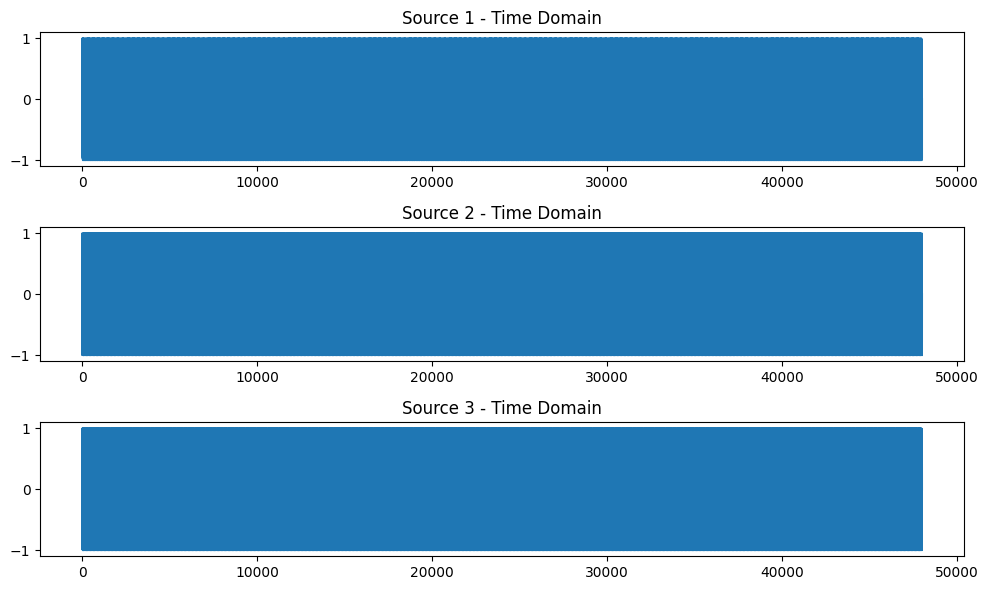

the gini index of this stft =  0.8678455409667197


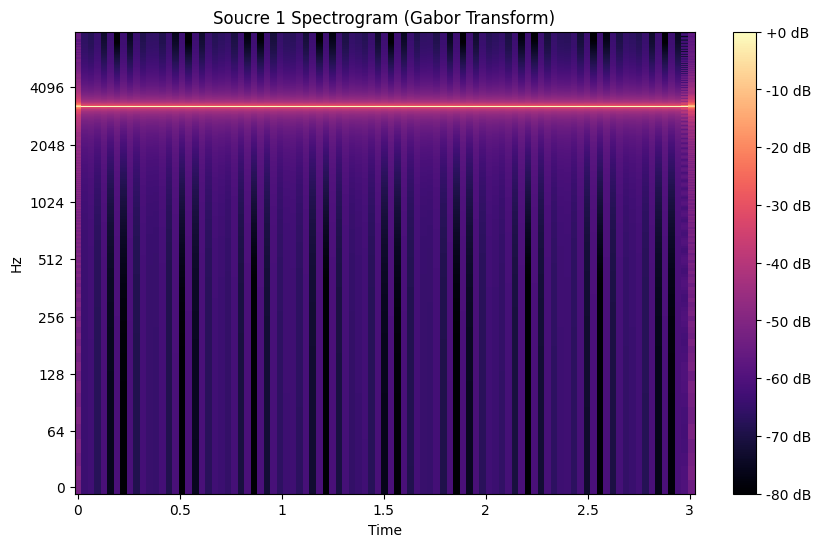

the gini index of this stft =  0.8810995443120908


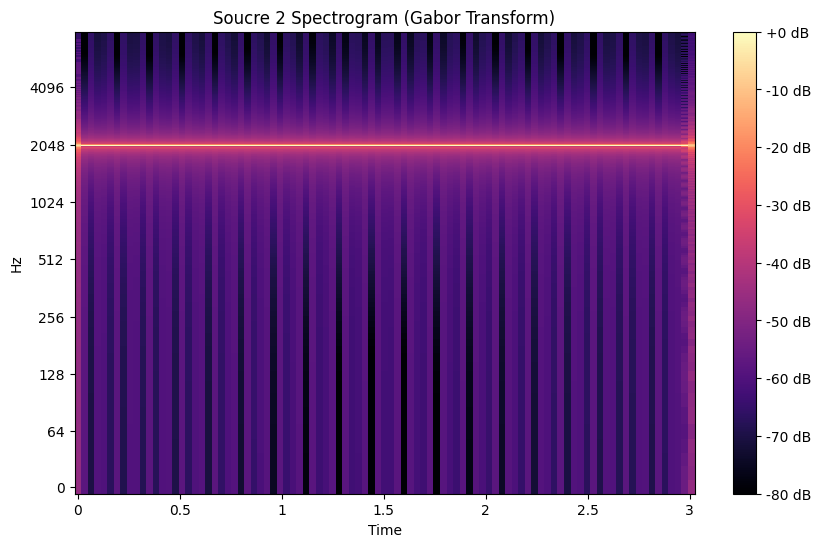

the gini index of this stft =  0.9381222515520882


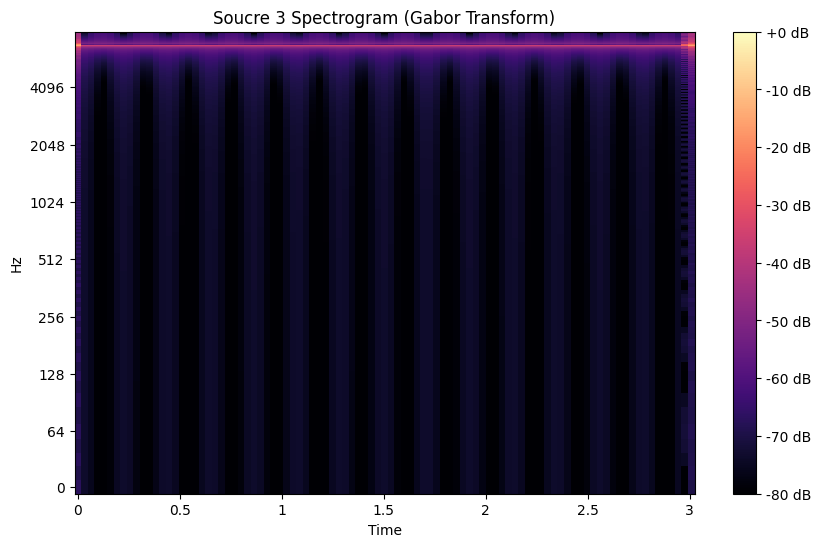

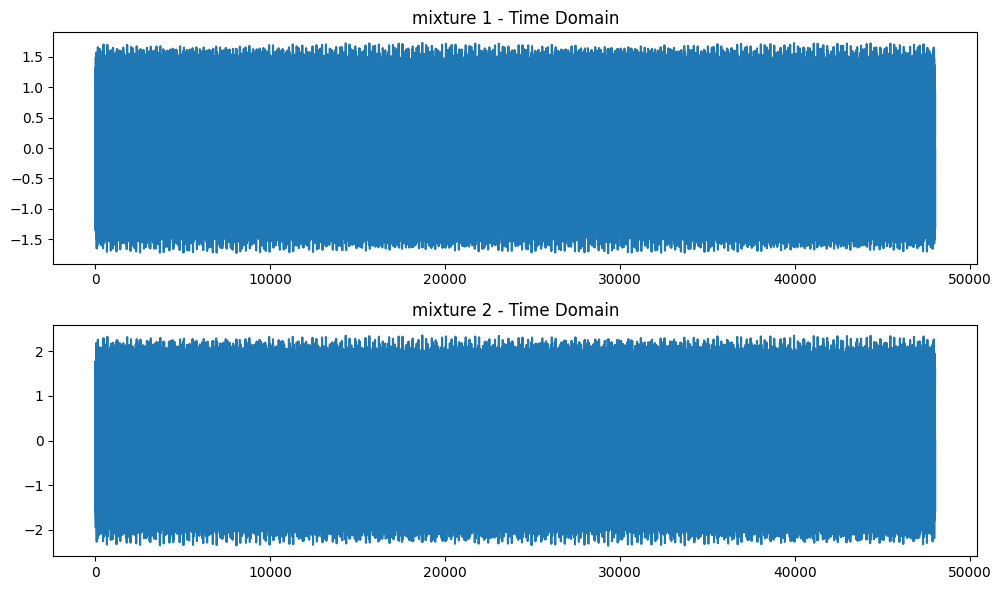

the gini index of this stft =  0.8887906015511353


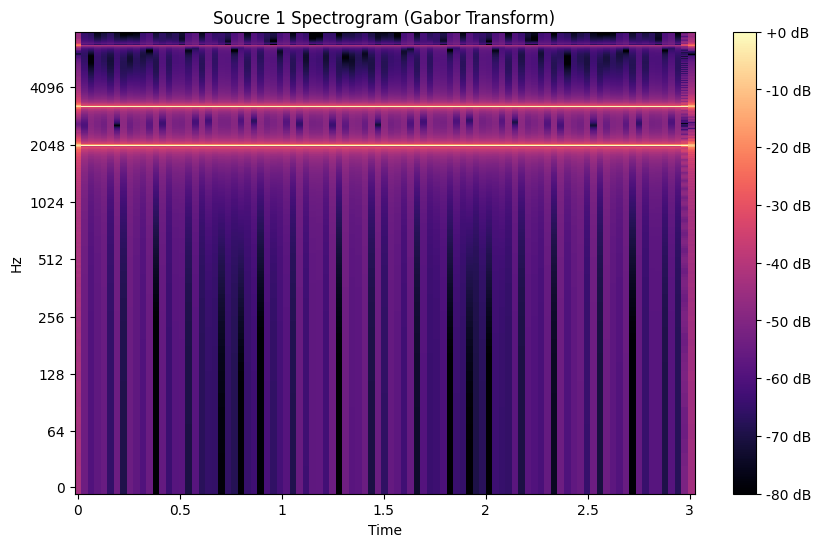

the gini index of this stft =  0.8912137677357358


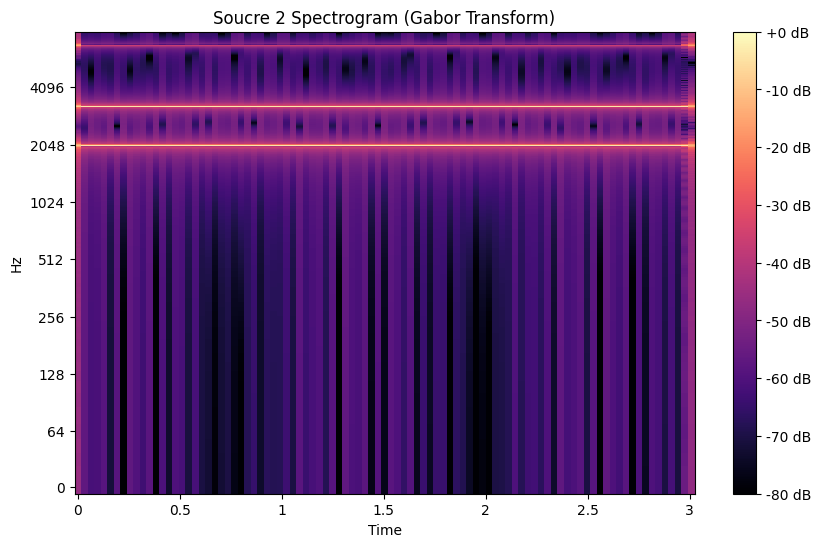

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)


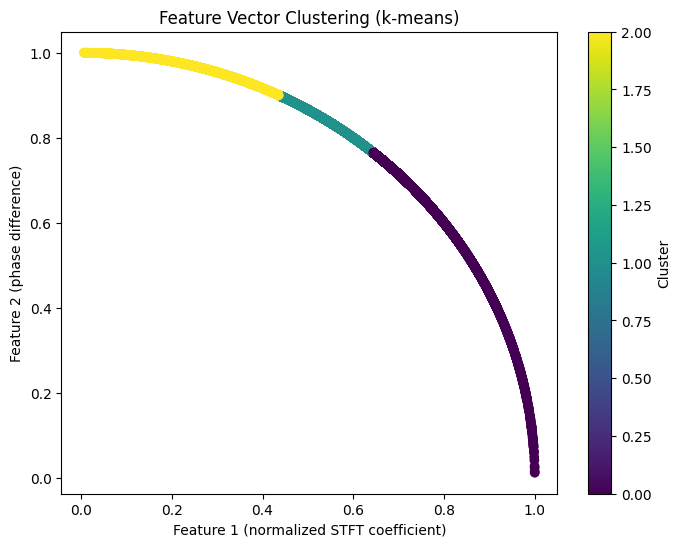

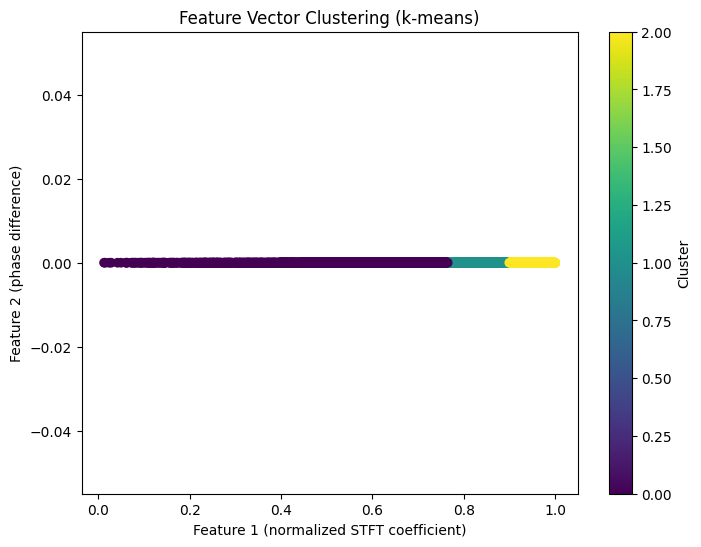

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:123: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)


The mean suqare error of delays is  nan
The True matrix is 
 [[0. 0.]
 [0. 0.]
 [0. 0.]]
The estiamted matrix is 
 [[0. 0.]
 [0. 0.]
 [0. 0.]]
The mean suqare error of attenutaion is  0.021755489907177114
The True matrix is 
 [[0.67528378 0.73755801]
 [0.73740285 0.67545321]
 [0.31773713 0.94817884]]
The estiamted matrix is 
 [[0.7217247  0.68560549]
 [0.54871885 0.83278681]
 [0.32286215 0.94280564]]
The mean suqare error of attenutaion is  0.021755489907177114
the gini index of this stft =  0.8970060264166457


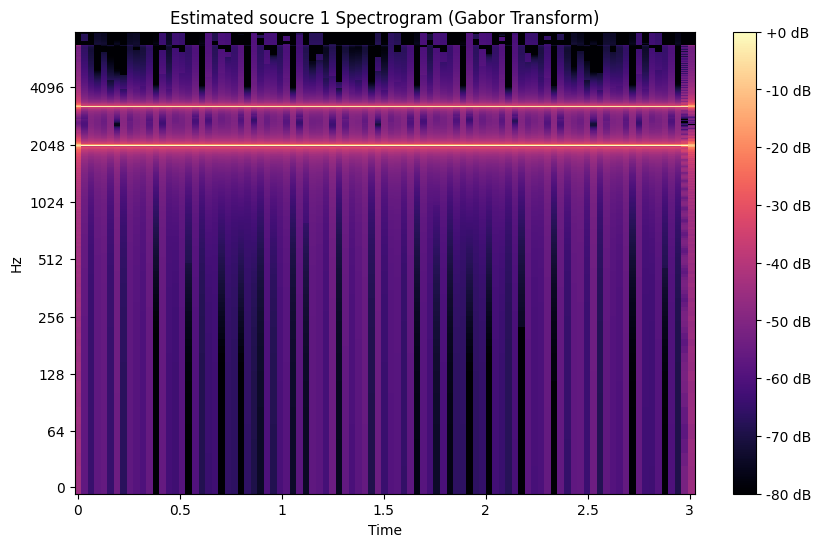

the gini index of this stft =  0.9262455150929043


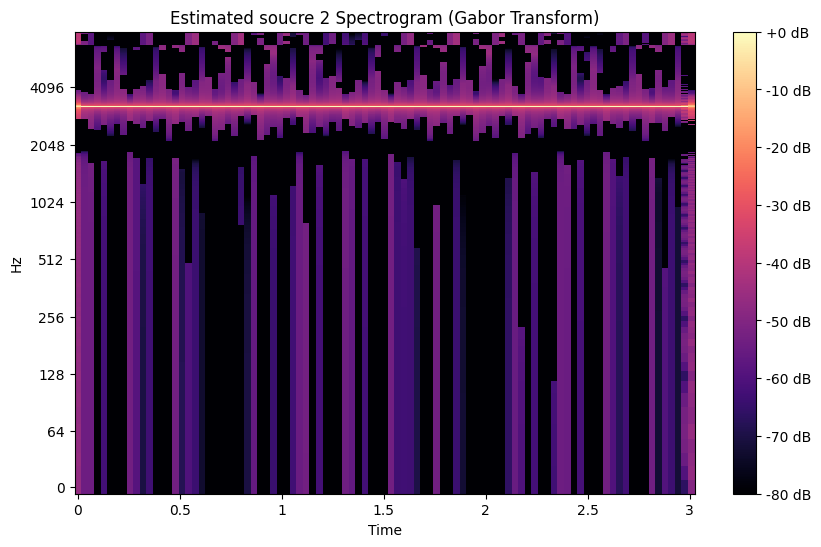

the gini index of this stft =  0.9565891551161647


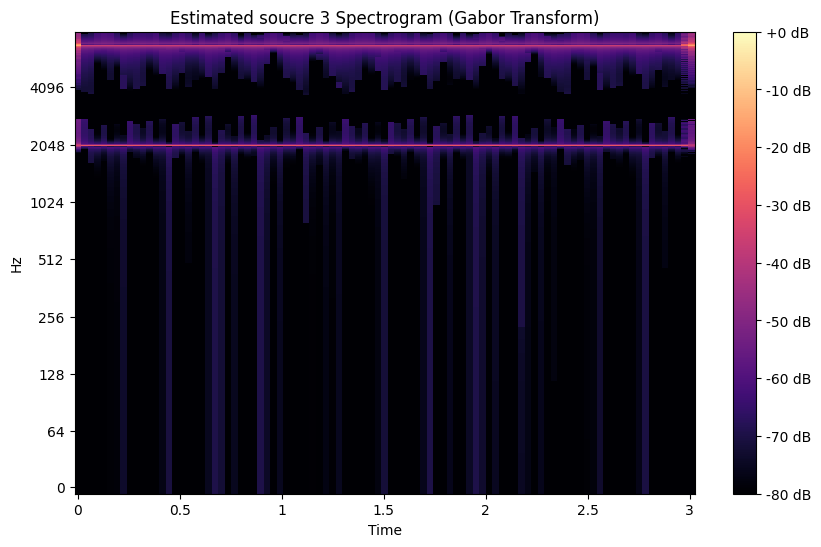

In [113]:
n_sources = 3
n_mixtures = 2 
duration = 3
sr=16000
f_max= 8000
f_min = 10 
min_spacing= (f_max- f_min)//10
method= 'IRLS'
sources = generate_sources(n_sources, duration, sr, f_min=f_min, f_max=f_max, min_spacing=min_spacing)
plot_time_domain_signals(sources, sr, 'Source')
sources_stft,f,t = compute_gabor_transform_with_f_t(sources, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian')
for i, stft in enumerate(sources_stft, 1):
    print( "the gini index of this stft = ", gini_index(stft,matrix=True))
    plot_spectrogram(stft, sr=sr, title=f"Soucre {i} Spectrogram (Gabor Transform)")

mixing_matrix = np.random.rand(n_mixtures, n_sources)  # Random mixing matrix
mixing_matrix = mixing_matrix / np.linalg.norm(mixing_matrix, axis=0)  # Normalize columns
delays = np.random.rand(n_mixtures, n_sources) *0 
mixtures = simulate_mixing(sources, mixing_matrix, delays, sr)
plot_time_domain_signals(mixtures, sr, 'mixture')

mixtures_stft,f,t = compute_gabor_transform_with_f_t(mixtures, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian')
for i, stft in enumerate(mixtures_stft, 1):
    print( "the gini index of this stft = ", gini_index(stft,matrix=True))
    plot_spectrogram(stft, sr=sr, title=f"Soucre {i} Spectrogram (Gabor Transform)")

system1= System(mixtures, n_sources, window_size= window_size,hop_length=hop_length,sr= sr)
system1.compute_gabor_transform_with_f_t()
system1.compute_feature_vectors()
best_mse=np.inf
best_attentuation= None
for _ in range(N_essays): 
    system1.compute_k_means()
    system1.estimate_aij_and_deltaij()
    system1.delays_est=system1.delays_est 
    system1.Mean_S_E_without_print(mixing_matrix,delays)
    if system1.mse < best_mse : 
        best_attentuation = system1.attenuations_est
    if system1.mse < eps : 
       break
system1.plot_clusters(indx1=0, indx2=1)
system1.plot_clusters(indx1=1, indx2=2)
system1.attenuations_est= best_attentuation
system1.Mean_S_E(mixing_matrix,delays)
results_method[mn]= system1.mse
print( "The mean suqare error of attenutaion is ", system1.mse)
system1.simulate_sources_stft(method_name=method,method_params=method_parameters[method] )
rt=system1.get_sources_stft()
for i, stft in enumerate(rt, 1):
     print( "the gini index of this stft = ", gini_index(stft,matrix=True))
     plot_spectrogram(stft, sr=sr, title=f"Estimated soucre {i} Spectrogram (Gabor Transform)")




# étude d' un cas réel 

In [114]:
sr=48000
audio_paths=['sample-000000.mp3','sample-000002.mp3','sample-000013.mp3']
def read_sources(audio_paths=audio_paths, sr=sr):
    sources= []
    for audio_path in audio_paths:
        audio, sr = librosa.load(audio_path, sr=sr)  # sr is the sample rate (set to 16kHz)
        first_3_seconds = audio[:sr*3] 
        sources.append(first_3_seconds)
        
    sources=np.array(sources)
    return sources
sources= read_sources(audio_paths)

In [115]:
method_names=['IRLS','proximal','CVXPY']
method_parameters={}
method_parameters['proximal']= {'q': 0.001, 'lambda_param': 0.001, 'max_iter': 2*150}

method_parameters['IRLS']= {'K': 50 , 'q': 0.5}
method_parameters['CVXPY']={'q': 1, 'epsilon': 1e-8}

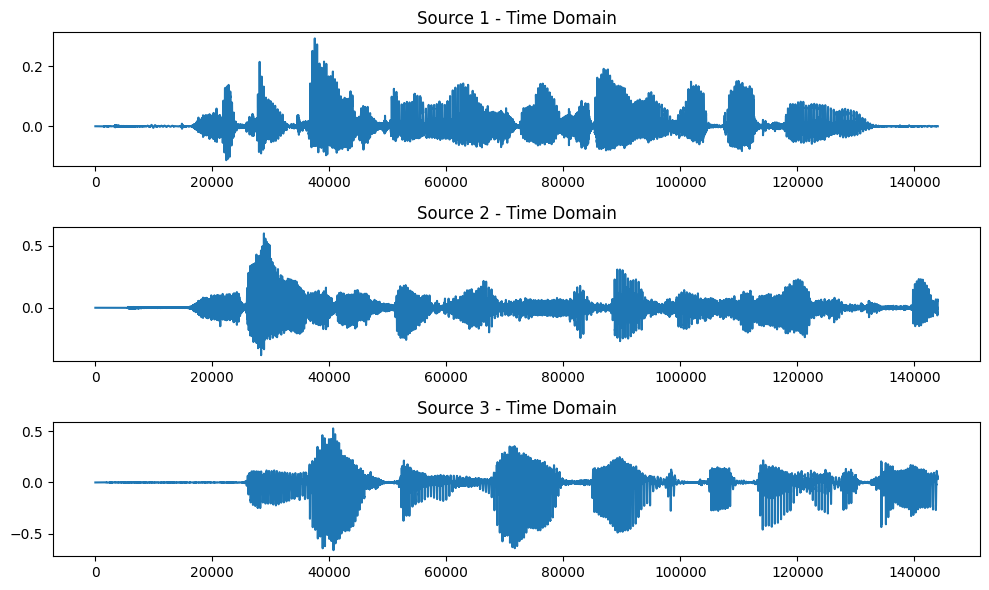

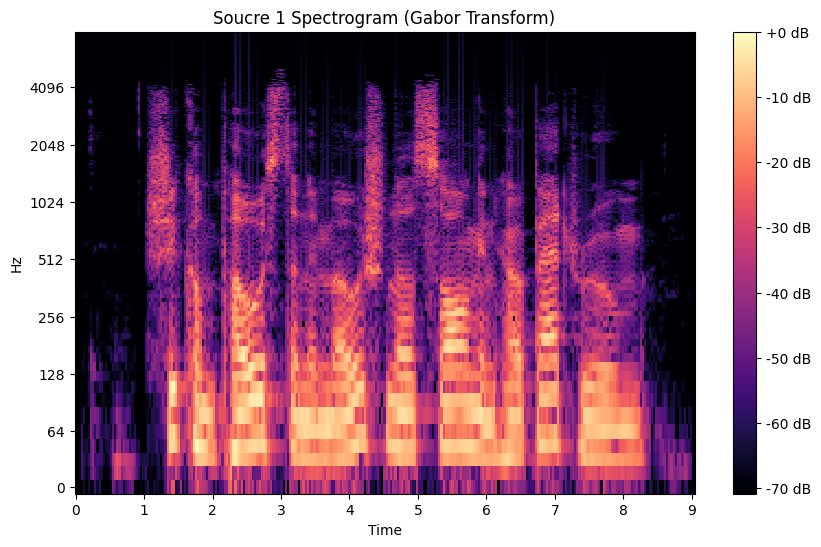

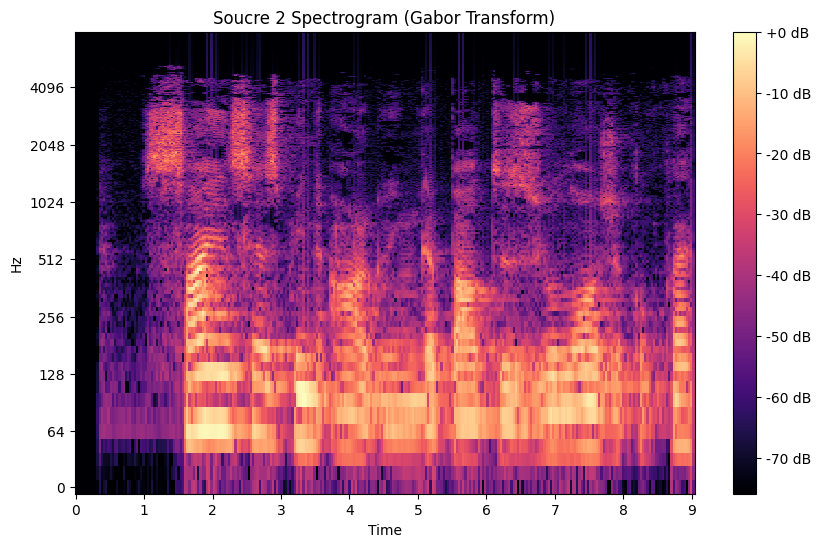

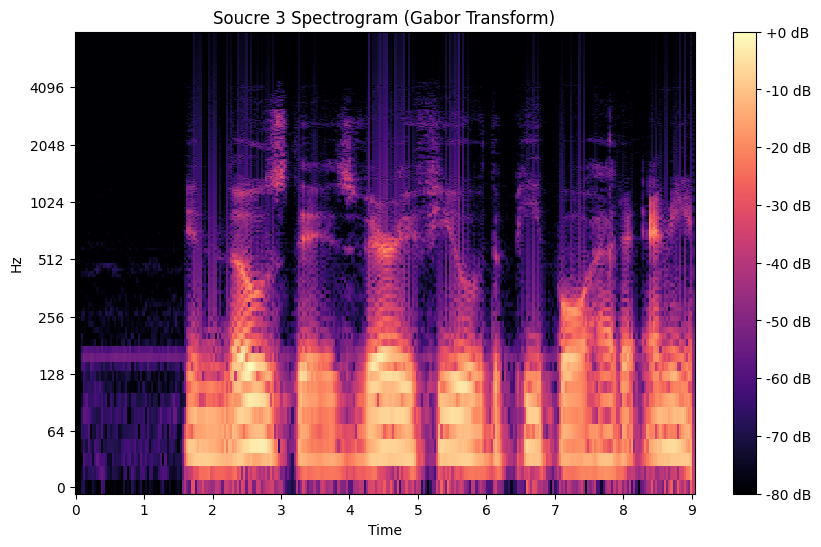

In [116]:
N_essays= 150
n_sources = 3
n_mixtures = 2 
duration = 3
sr=16000
f_max= 8000
f_min = 10 
min_spacing= (f_max- f_min)//10
method= 'IRLS'
sources= read_sources(audio_paths)
plot_time_domain_signals(sources, sr, 'Source')
sources_stft,f,t = compute_gabor_transform_with_f_t(sources, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian')
for i, stft in enumerate(sources_stft, 1):
    plot_spectrogram(stft, sr=sr, title=f"Soucre {i} Spectrogram (Gabor Transform)")

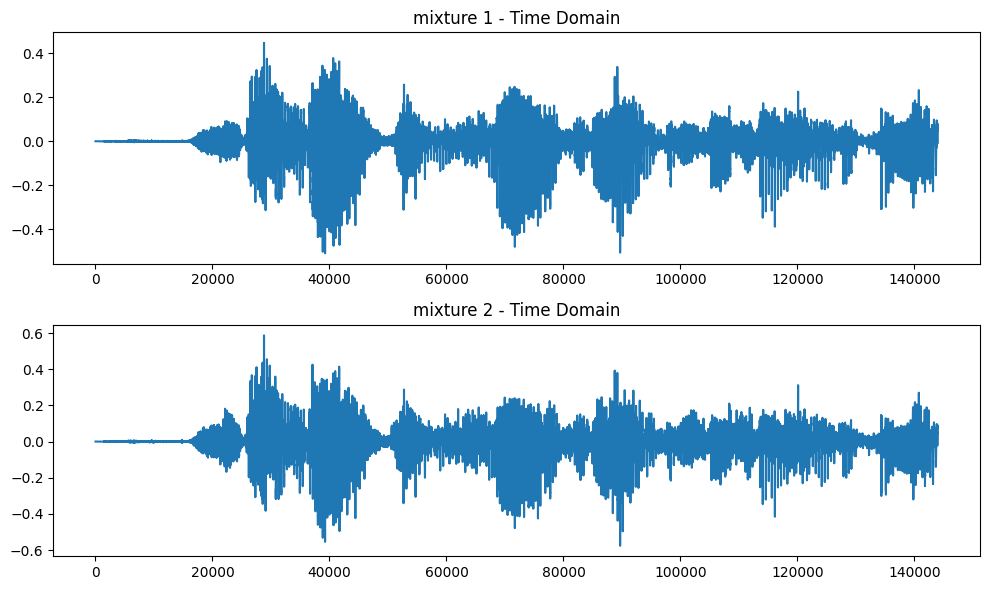

the gini index of this stft =  0.9236980953680484


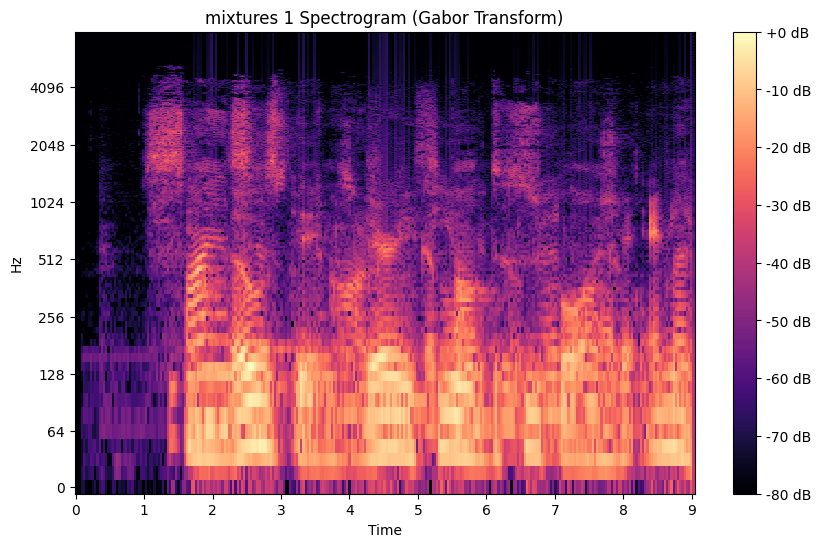

the gini index of this stft =  0.9140464487613443


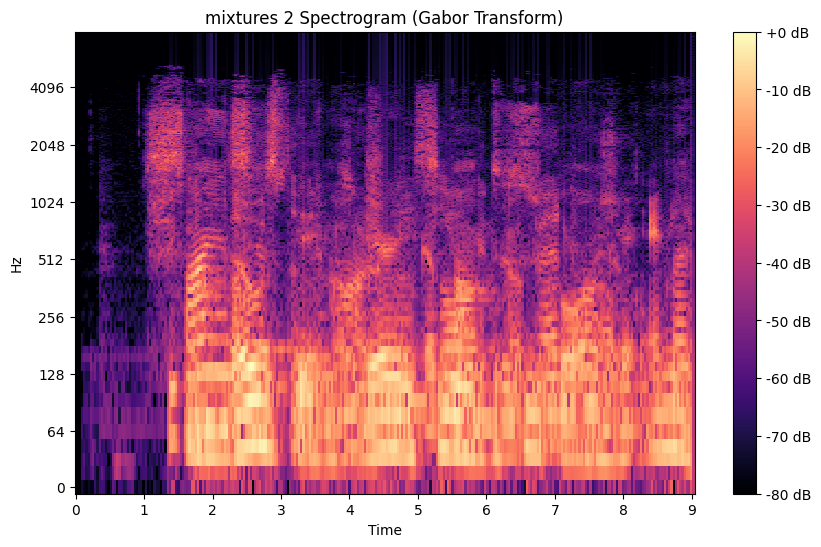

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)


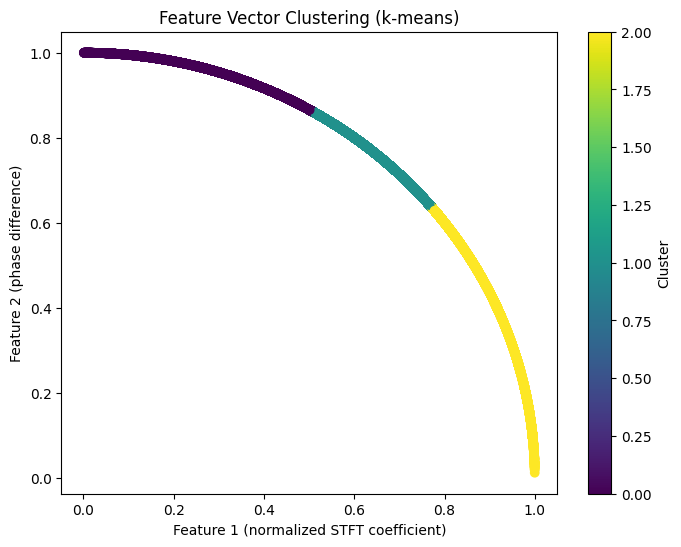

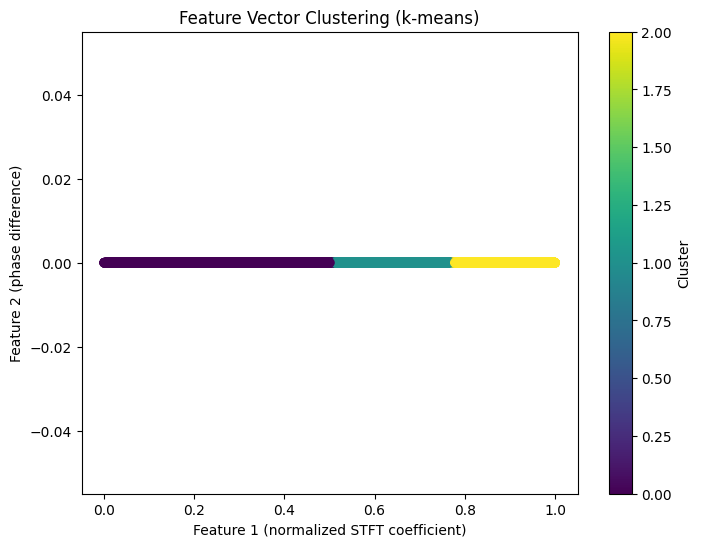

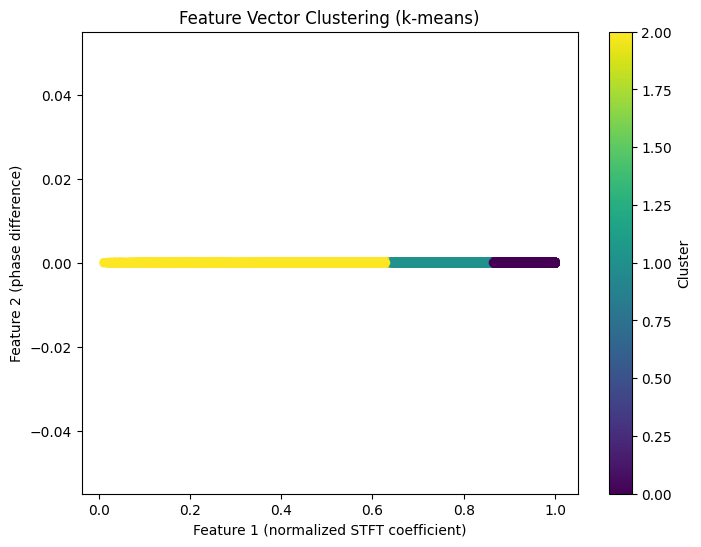

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2054076689.py:123: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)


The mean suqare error of delays is  nan
The True matrix is 
 [[0. 0.]
 [0. 0.]
 [0. 0.]]
The estiamted matrix is 
 [[0. 0.]
 [0. 0.]
 [0. 0.]]
The mean suqare error of attenutaion is  0.025047589385908776
The True matrix is 
 [[0.31714668 0.9483765 ]
 [0.61566022 0.78801173]
 [0.71504335 0.69908012]]
The estiamted matrix is 
 [[0.35833837 0.92589471]
 [0.63918269 0.76522477]
 [0.86339677 0.47578817]]
The mean suqare error of attenutaion is  0.025047589385908776
the gini index of this stft =  0.9297526280758837


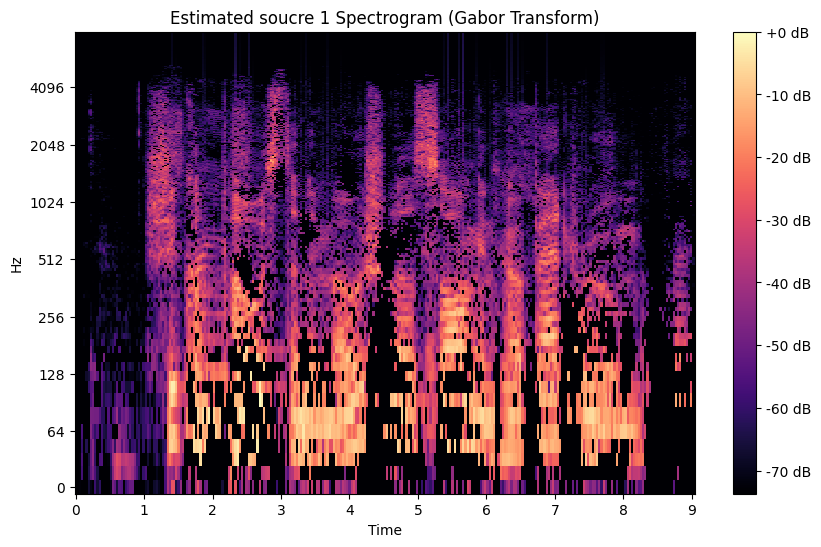

the gini index of this stft =  0.9457302940664515


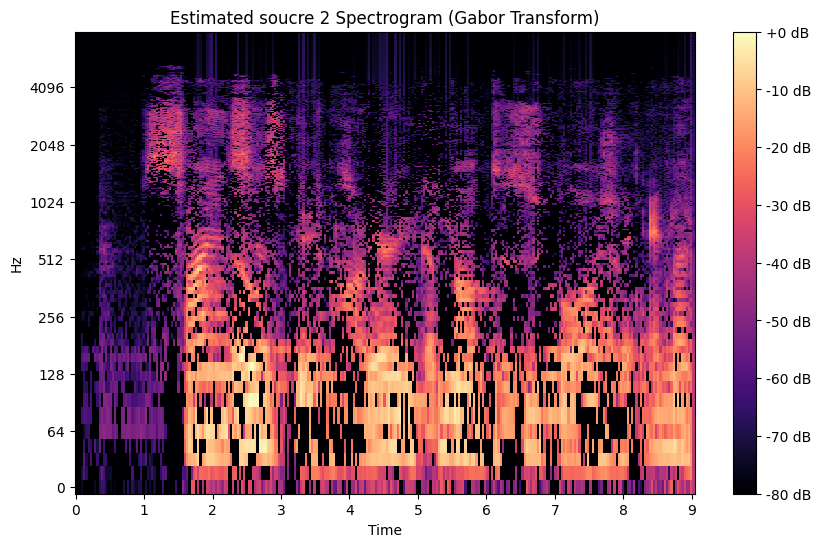

the gini index of this stft =  0.9658666707410966


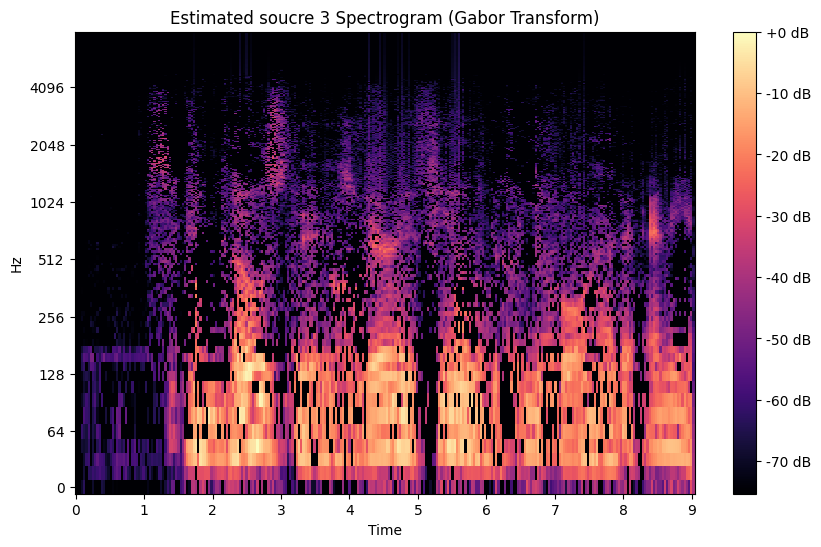

In [117]:


mixing_matrix = np.random.rand(n_mixtures, n_sources)  # Random mixing matrix
mixing_matrix = mixing_matrix / np.linalg.norm(mixing_matrix, axis=0)  # Normalize columns
delays = np.random.rand(n_mixtures, n_sources) *0 
mixtures = simulate_mixing(sources, mixing_matrix, delays, sr)
plot_time_domain_signals(mixtures, sr, 'mixture')

mixtures_stft,f,t = compute_gabor_transform_with_f_t(mixtures, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian')
for i, stft in enumerate(mixtures_stft, 1):
    print( "the gini index of this stft = ", gini_index(stft,matrix=True))
    plot_spectrogram(stft, sr=sr, title=f"mixtures {i} Spectrogram (Gabor Transform)")

system1= System(mixtures, n_sources, window_size= window_size,hop_length=hop_length,sr= sr)
system1.compute_gabor_transform_with_f_t()
system1.compute_feature_vectors()
best_mse=np.inf
best_attentuation= None
for _ in range(N_essays): 
    system1.compute_k_means()
    system1.estimate_aij_and_deltaij()
    system1.delays_est=system1.delays_est 
    system1.Mean_S_E_without_print(mixing_matrix,delays)
    if system1.mse < best_mse : 
        best_attentuation = system1.attenuations_est
    if system1.mse < eps : 
       break
system1.plot_clusters(indx1=0, indx2=1)
system1.plot_clusters(indx1=0, indx2=2)
system1.plot_clusters(indx1=1, indx2=2)
system1.attenuations_est= best_attentuation
system1.Mean_S_E(mixing_matrix,delays)
results_method[mn]= system1.mse
print( "The mean suqare error of attenutaion is ", system1.mse)
system1.simulate_sources_stft(method_name=method,method_params=method_parameters[method] )
rt=system1.get_sources_stft()
for i, stft in enumerate(rt, 1):
     print( "the gini index of this stft = ", gini_index(stft,matrix=True))
     plot_spectrogram(stft, sr=sr, title=f"Estimated soucre {i} Spectrogram (Gabor Transform)")




In [122]:
from IPython.display import Audio
def reconstruct_signal_from_gabor(gabor_transforms, window_size=1024, hop_length=512, window_type='gaussian'):
    reconstructed_signals = []
    
    for Zxx in gabor_transforms:
        if window_type == 'gaussian':
            window = signal.windows.gaussian(window_size, std=window_size / 4)
        else:
            window = signal.windows.get_window(window_type, window_size)

        # Inverse STFT to reconstruct the signal
        _, reconstructed_signal = signal.istft(Zxx, nperseg=window_size, noverlap=hop_length, window=window)
        reconstructed_signals.append(reconstructed_signal)
    
    return np.array(reconstructed_signals)


reconstructed_signals= reconstruct_signal_from_gabor(rt, window_size=1024, hop_length=512, window_type='gaussian')

Audio(reconstructed_signals[2], rate=sr*3)


In [119]:
Audio(mixtures[0], rate=sr*3)

In [120]:
Audio(reconstructed_signals[0], rate=sr*3)